In [61]:
import os
import cv2 as cv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
from regularization import Perturbation, Regularization, RegParameters
from models import AnimalClassifier
from data import get_train_data, get_valid_data
from typing import List  
import json
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [62]:
def load_pixel_info(path: str, saliency_map: torch.Tensor):
    """
    Loads already computed pixel information scores from the file and updates the saliency map.
    Returns the updated saliency map and the starting index for new computations.
    
    :param path: File path containing previously computed pixel importance scores.
    :param saliency_map: A tensor to update with loaded values.
    :return: Updated saliency map and the starting index for further computations.
    """
    start_idx = 0
    if os.path.exists(path):
        with open(path, 'r') as f:
            for line in f:
                parts = line.strip().split(', ')
                if len(parts) == 2:
                    idx = int(parts[0].split(': ')[1])
                    imp = float(parts[1].split(': ')[1])
                    saliency_map[idx] = imp
                    start_idx = max(start_idx, idx + 1)
    return saliency_map, start_idx

In [87]:
def get_saliency_map(image: torch.Tensor, save_path: str = 'pixel_info.txt', normalize: bool = False) -> torch.Tensor:
    """
    Computes an information map for a single image for a specific label using batched perturbations.
    
    Processes pixels in batches and appends the computed importance values to the file at save_path.

    :param image: A single image tensor of shape (1, 3, H, W) with requires_grad=True.
    :param save_path: File path to which pixel importance results will be appended.
    :return: A tensor of shape (H, W) with the importance score for each pixel.
    """
    _, C, H, W = image.shape
    num_pixels = H * W
    saliency_map = torch.zeros((num_pixels,), device=image.device)
    
    # Load existing pixel information
    saliency_map, start_idx = load_pixel_info(save_path, saliency_map)
    
    if normalize:
        print(saliency_map[0])
        saliency_map = (saliency_map - saliency_map.mean()) / saliency_map.std()
        print(saliency_map[0])
    
    return saliency_map.view(H, W)

In [85]:
def extract_info_map_from_image(image_path: str, labels) -> torch.Tensor:
    """
    Extracts pixel information scores from an existing image where the saliency maps are embedded.
    This function assumes that the image has three channels, two of which contain saliency maps.
    
    :param image_path: Path to the image containing the embedded saliency maps.
    :return: A dictionary containing the extracted pixel-wise importance scores.
    """
    img = cv.imread(image_path, cv.IMREAD_UNCHANGED)
    if img is None:
        print(f"Error loading image from {image_path}")
        return None
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    #img = cv.resize(img, (224, 224))
    
    # Split the image into three sections assuming it's a horizontally stacked image
    img_width = img.shape[1] // 3
    original_img = img[:, :img_width]
    saliency_map_1 = img[:, img_width:2*img_width, 0]  # Extract first saliency map from first channel
    saliency_map_2 = img[:, 2*img_width:, 0]  # Extract second saliency map from first channel
    
    print(saliency_map_1.shape)
    
    saliency_maps = {
        "original": torch.tensor(original_img, dtype=torch.float32),
        f"{labels[0]}": torch.tensor(saliency_map_1, dtype=torch.float32),
        f"{labels[1]}": torch.tensor(saliency_map_2, dtype=torch.float32)
    }
    
    return saliency_maps

In [88]:
def show_information_map(image_path: str, labels: list, from_txt: bool=False) -> None:
    """
    Loads an image from IMAGE_PATH, extracts the two ground truth labels from its filename (expected format: 
    "Label1_Label2.png"), computes a pixel-level information map for each label using the developed method, and 
    displays the original image alongside the maps.
    
    :param image_path: Path to the image file.
    :param labels: List of valid labels. The image filename should contain two labels separated by an underscore.
    :param reg_params: Regularization parameters.
    :return: None. Displays the original image and its information maps.
    """
    # Load and preprocess the image
    img = cv.imread(image_path)
    if img is None:
        print(f"Error loading image from {image_path}")
        return
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (224, 224))
    
    # Convert to tensor: shape (1, 3, 224, 224)
    img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)
    
    # Extract ground truth labels from filename
    base_name = os.path.basename(image_path)
    name_no_ext, _ = os.path.splitext(base_name)
    gt_labels = name_no_ext.split('_')[-2:]
    print(f"Ground truth labels: {gt_labels}")
    if len(gt_labels) < 2:
        print("Warning: Expected at least 2 labels in filename (e.g., Giraffe_Lion.png)")   
    
    info_maps = {}
    for label in gt_labels:
        print(f"Computing information map for label: {label}")
        PIXEL_INFO_PATH = f"pixel_info_{name_no_ext}_" 
        PIXEL_INFO_PATH = PIXEL_INFO_PATH + label + ".txt"   
    
        try:
            label_idx = labels.index(label)
        except ValueError:
            print(f"Label '{label}' not found in the provided labels list.")
            continue
        
        if from_txt:
            sal_map = get_saliency_map(img_tensor, PIXEL_INFO_PATH)
        else: 
            image_path_info_map = "pixels_info/info_map_Giraffe_Lion.png" # "info_map_" + gt_labels[0] +"_" + gt_labels[1] +".png"
            sal_map = extract_info_map_from_image(image_path_info_map, gt_labels)
            sal_map = sal_map[label]
            print(sal_map.shape)

        info_maps[label] = sal_map.detach().cpu().numpy()
        
        
        del sal_map
        torch.cuda.empty_cache()
        gc.collect()
    
    # Display the original image and information maps
    num_plots = len(info_maps) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    for i, (label, info_map) in enumerate(info_maps.items(), start=1):
        axes[i].imshow(info_map, cmap='hot')
        axes[i].set_title(f"Info Map: {label}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()
    
    info_map_path = f"info_map_{gt_labels[0]}_{gt_labels[1]}.png"
    fig.savefig(info_map_path)
    print(f"Information map saved to {info_map_path}")
    
    del info_maps, img_tensor
    torch.cuda.empty_cache()
    gc.collect()



In [66]:
def load_config(config_path: str) -> dict:
    """
    Loads the configuration from a JSON file.
    
    :param config_path: Path to the JSON config file.
    :return: A dictionary with configuration parameters.
    """
    with open(config_path, 'r') as f:
        config = json.load(f)
    return config


Ground truth labels: ['Horse', 'Zebra']
Computing information map for label: Horse
Computing information map for label: Zebra


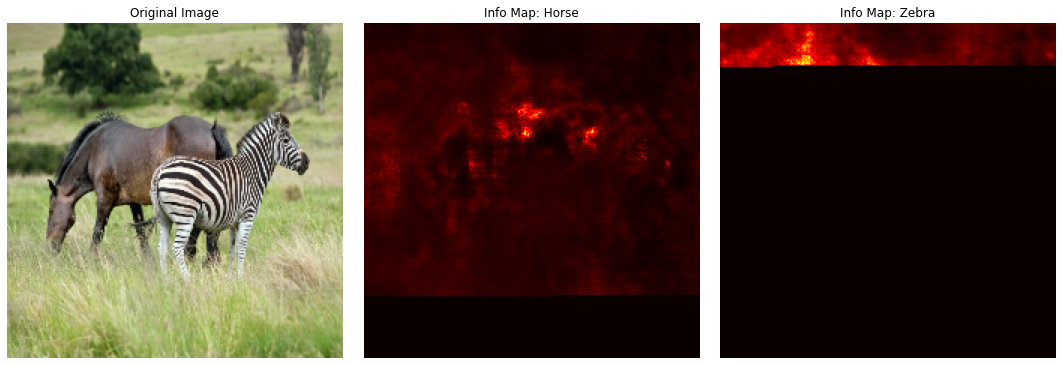

Information map saved to info_map_Horse_Zebra.png


In [90]:
config = load_config('config.json')
labels = config.get('labels', [])
num_classes = len(labels)

IMAGE_PATH = "images2explain/Giraffe_Lion.png" 
#IMAGE_PATH = "pixels_info/info_map_Giraffe_Lion.png"
IMAGE_PATH = "images2explain/Horse_Zebra.png"
show_information_map(IMAGE_PATH, labels, from_txt=True)

In [78]:
IMAGE_PATH = "pixels_info/info_map_Giraffe_Lion.png" #"images2explain/Giraffe_Lion.png"
labels = IMAGE_PATH.split('.')[0].split('_')[-2:]
saliency_maps = extract_info_map_from_image(IMAGE_PATH, labels)
